<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Постановка-задачи" data-toc-modified-id="Постановка-задачи-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Постановка задачи</a></span></li><li><span><a href="#Критерии-успеха" data-toc-modified-id="Критерии-успеха-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Критерии успеха</a></span></li><li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Описание данных</a></span></li><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

Проект сделан на основе выработанного шаблона:
- https://github.com/evgeny-ydsc/first-project/blob/main/шаблон%20проекта/шаблон%20проекта.ipynb

#  Проект по временным рядам: Прогнозирование заказов такси

## Постановка задачи

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно **спрогнозировать количество заказов такси на следующий час**.
**Постройте модель** для такого предсказания.

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.

## Критерии успеха
- Значение метрики **RMSE на тестовой выборке должно быть не больше 48**.

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

## Описание данных

Данные лежат в файле `taxi.csv`. 

- **Целевой признак:** Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
                                

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

import re
#import time

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import TimeSeriesSplit

In [2]:
RANDOM_STATE = 42

In [3]:
def correct_path (csv_name, folder=""):
    if not os.path.exists(folder + csv_name):
        return '/datasets/' + csv_name
    return folder + csv_name

def show_nans (df):
    n = df.isna().sum()
    l = df.shape[0]
    display("empty parts:")
    display(n [n>0].map(lambda x: f'{round(x/l*100, 2)}%'))

In [4]:
df = pd.read_csv (correct_path('taxi.csv'), index_col=[0], parse_dates=[0]).resample('1H').sum()

In [5]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


In [7]:
print(df.index.is_monotonic)

True


Отсортируем индекс и аггрегируем по часам:

In [8]:
df.sort_index(inplace=True)
##v3 df = df.resample('1h').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


Посмотрим, нет ли пропусков:

In [9]:
show_nans (df)

'empty parts:'

Series([], dtype: object)

Пропусков нет

## Анализ

- Все данные - с марта по август 2018 года. Значит сезонные тренды мы построить не сможем (например нет новогодних праздников)
- статитика по каждому месяцу похожа - чуть превышает 4000
- статитика по каждому дню недели похожа - в интервале от 3500 до 4000
- статитика по каждому часу - около 900
    - это странно, что ночью - столько же заказов, сколько и днём в случае, если это один локальный регион (если же это большая международная сеть такси - то это менее странно)

Посмотрим на исходные данные, аггрегированные по часам:

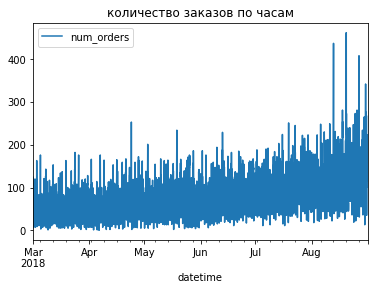

In [10]:
df.plot(title='количество заказов по часам');

Количество заказов увеличиваетя к августу (растёт и среднее, и разбос). Возможно, это связано с отпусками и с возвращением школьников с каникул.

Оценим также график скользящего недельного окна:

<AxesSubplot:xlabel='datetime'>

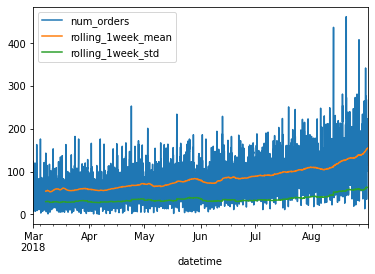

In [11]:
df['rolling_1week_mean'] = df['num_orders'].rolling(24*7).mean()
df['rolling_1week_std'] = df['num_orders'].rolling(24*7).std()

df.plot()

Видно, что наш ряд нестационарный (и среднее, и отклонение - меняются со временем)

In [12]:
# код ревьювера
from statsmodels.tsa.stattools import adfuller

taxi = pd.read_csv(correct_path('taxi.csv'), index_col=[0], parse_dates=[0]).resample('1H').sum()

ts = taxi['num_orders']
st_test = adfuller(ts, regression='ctt')

print('Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный')
if st_test[1] < 0.05:
    print('Наш ряд стационарный')
else:
    print('Ряд нестационарный')



Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный
Наш ряд стационарный


Да, явно виден рост.

Хотя данных за полный год (и за полных несколько лет) нет, посмотрим, тем не менее, что покажет функция seasonal_decompose:

In [13]:
decomposed = seasonal_decompose(df['num_orders'])

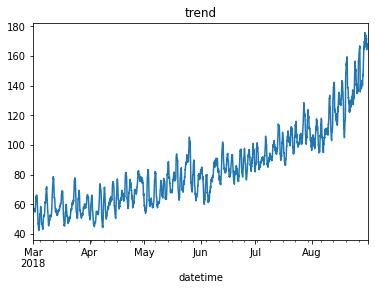

In [14]:
decomposed.trend.plot(ax=plt.gca())
plt.title('trend');

Тренд рост подтверждён и этим способом.

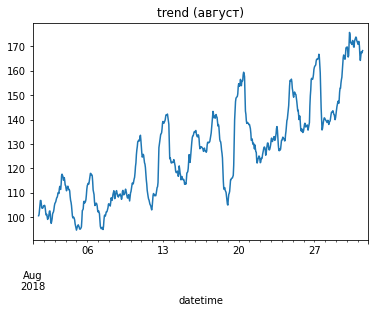

In [15]:
decomposed_aug = seasonal_decompose(df.loc['2018-08', 'num_orders'])
decomposed_aug.trend.plot(ax=plt.gca())
plt.title('trend (август)');

Text(0.5, 1.0, 'Seasonality')

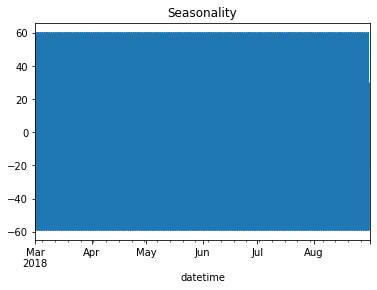

In [16]:
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')

Сезонных составляющих не выявлено.

In [ ]:
df0 = pd.read_csv(correct_path('taxi.csv'), index_col=[0], parse_dates=[0])
df_1d = df0.resample('1D').sum()

df_7d = df0.resample('7D').sum()

In [18]:
def plot_decomposed(df, caption):
    decomposed = seasonal_decompose(df)
    decomposed.trend.plot(figsize=(7, 2))
    plt.title(f'Trend ({caption})')
    plt.show();
    
    decomposed.seasonal.plot(figsize=(7, 2))
    plt.title(f'Seasonality ({caption})');
    plt.show();

    decomposed.resid.plot(figsize=(7, 2))
    plt.title(f'Residuals ({caption})');
    plt.show();

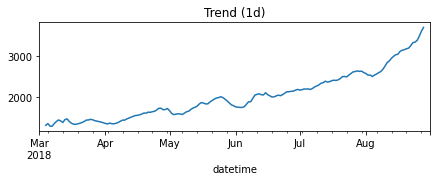

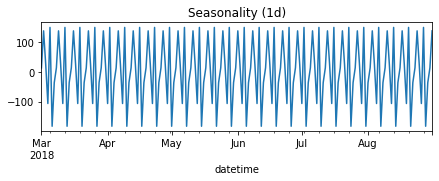

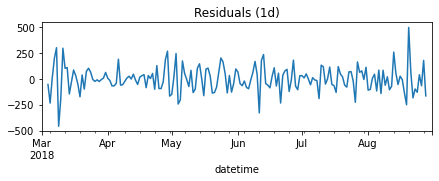

In [19]:
plot_decomposed (df_1d, '1d')

Для 7 дней я получил ошибку:

`ValueError: x must have 2 complete cycles requires 104 observations. x only has 27 observation(s)`

Не очень пока понятно, что тут не так. Видимо, нужны хотя бы 104 строки. А у нас их 27 ~(6 месяцев * 4.5 недели).

Итого, тренд при ресемплировании в 1 день уже не пляшет как кардиограмма - можно ориентироваться на него. Значит признаки - групировка по часу.

> Альтернативно здесь можно было бы попробовать сгруппировать данные по признаку часа и по признаку дня недели, посмотреть столбчатые диаграммы.

In [22]:
df_tmp = df0.resample('1H').sum()
df_tmp['hour'] = df_tmp.index.hour
df_tmp['dayofweek'] = df_tmp.index.dayofweek

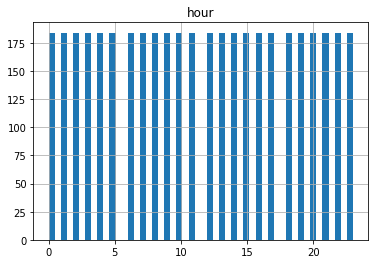

In [23]:
df_tmp.hist(column='hour', bins=50);

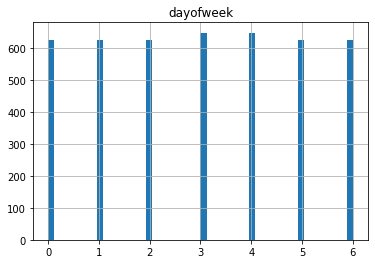

In [24]:
df_tmp.hist(column='dayofweek', bins=50);

Вне привязки к месяцам - особой разницы в количестве заказов по часам нет (как и по дням недели). Объяснение Кирилла выше - мы в аэропорту.

## Обучение

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   num_orders          4416 non-null   int64  
 1   rolling_1week_mean  4249 non-null   float64
 2   rolling_1week_std   4249 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 138.0 KB


In [26]:
##v1 df = df.drop(columns=['rolling_1week_std'])

Создадим дополнительные признаки

In [27]:
'''v1
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
'''
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

In [28]:
for lag in range (2, 24):
    df[f'lag_{lag}h'] = df['num_orders'].shift(lag)
for lag in range (12, 169, 12):
    df[f'lag_{lag}h'] = df['num_orders'].shift(lag)

In [29]:
df[f'rolling_mean_3h'] = df['num_orders'].shift().rolling(3).mean() 

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   num_orders          4416 non-null   int64  
 1   rolling_1week_mean  4249 non-null   float64
 2   rolling_1week_std   4249 non-null   float64
 3   hour                4416 non-null   int64  
 4   dayofweek           4416 non-null   int64  
 5   lag_2h              4414 non-null   float64
 6   lag_3h              4413 non-null   float64
 7   lag_4h              4412 non-null   float64
 8   lag_5h              4411 non-null   float64
 9   lag_6h              4410 non-null   float64
 10  lag_7h              4409 non-null   float64
 11  lag_8h              4408 non-null   float64
 12  lag_9h              4407 non-null   float64
 13  lag_10h             4406 non-null   float64
 14  lag_11h             4405 non-null   float64
 15  lag_12h    

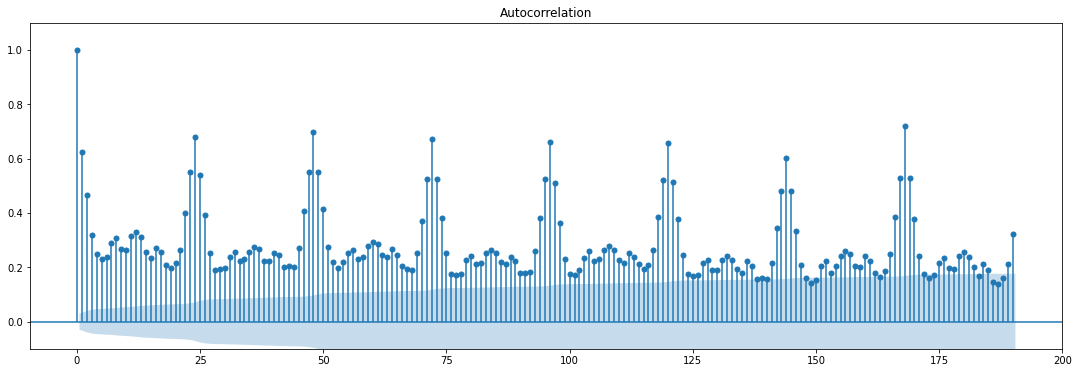

In [31]:
# Код ревьюера
from statsmodels.graphics import tsaplots

taxi = pd.read_csv(correct_path('taxi.csv'), index_col=[0], parse_dates=[0]).resample('1H').sum()
ts = taxi['num_orders']

fig = tsaplots.plot_acf(ts,lags= 190)
fig.set_size_inches(18.5, 6)
plt.ylim(-.1, 1.1)
plt.show() 



Удалим строки с NaN

In [32]:
df = df.dropna()

In [33]:
df.shape

(4248, 41)

In [34]:
df.head(2)

,num_orders,rolling_1week_mean,rolling_1week_std,hour,dayofweek,lag_2h,lag_3h,lag_4h,lag_5h,lag_6h,...,lag_72h,lag_84h,lag_96h,lag_108h,lag_120h,lag_132h,lag_144h,lag_156h,lag_168h,rolling_mean_3h
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,54.339286,29.899198,0,3,127.0,108.0,76.0,50.0,99.0,...,86.0,30.0,75.0,32.0,163.0,36.0,90.0,30.0,124.0,109.666667
2018-03-08 01:00:00,78,54.297619,29.861067,1,3,94.0,127.0,108.0,76.0,50.0,...,176.0,30.0,60.0,28.0,108.0,45.0,120.0,32.0,85.0,121.333333


Разобьём выборку на тренировочную и тестовую

In [35]:
X = df.drop(columns=['num_orders'])
y = df['num_orders']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.1)

Обучим модель

In [ ]:
pipe_final = Pipeline([
    ('models', LinearRegression())
]
)

In [ ]:
param_grid = [
    {
        'models': [LinearRegression()]  
    }
    ,
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': [3, 5, 10, None],
        'models__min_samples_split': [2, 5, 10] 
    },
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': [50, 100],
        'models__max_depth': [None, 10, 20],
        'models__min_samples_split': [2, 5]
    }
]

In [40]:
%%time
tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_iter=30,
    verbose = 1,
    n_jobs=-1
)

search.fit(X_train, y_train)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:285: UserWarning: The total space of parameters 25 is smaller than n_iter=30. Running 25 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 25 candidates, totalling 75 fits
CPU times: user 1min 21s, sys: 490 ms, total: 1min 21s
Wall time: 1min 22s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=Pipeline(steps=[('models', LinearRegression())]),
                   n_iter=30, n_jobs=-1,
                   param_distributions=[{'models': [LinearRegression()]},
                                        {'models': [DecisionTreeRegressor(random_state=42)],
                                         'models__max_depth': [3, 5, 10, None],
                                         'models__min_samples_split': [2, 5,
                                                                       10]},
                                        {'models': [RandomForestRegressor(random_state=42)],
                                         'models__max_depth': [None, 10, 20],
                                         'models__min_samples_split': [2, 5],
                                         'models__n_estimators': [50, 100]}],
                   scoring='neg_mean_squared_error', verb

In [41]:
search.best_params_

{'models': LinearRegression()}

In [42]:
best_model = search.best_estimator_

## Тестирование

Метрика качества лучшей модели на кроссвалидации:

In [44]:
(-1*search.best_score_)**0.5

22.858682850204872

Метрика качества на тестовой выборке

In [45]:
y_pred = best_model.predict(X_test)

In [46]:
mean_squared_error(y_test, y_pred)**0.5

34.49489957201152

Проведём также анализ остатков

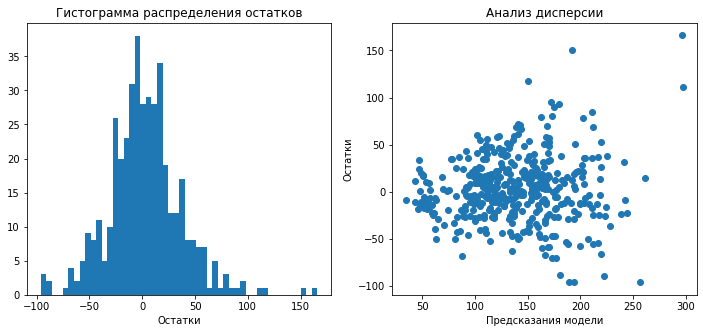

In [47]:
residuals = y_test - y_pred

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
axes[0].hist(residuals, bins=50)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(y_pred, residuals)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

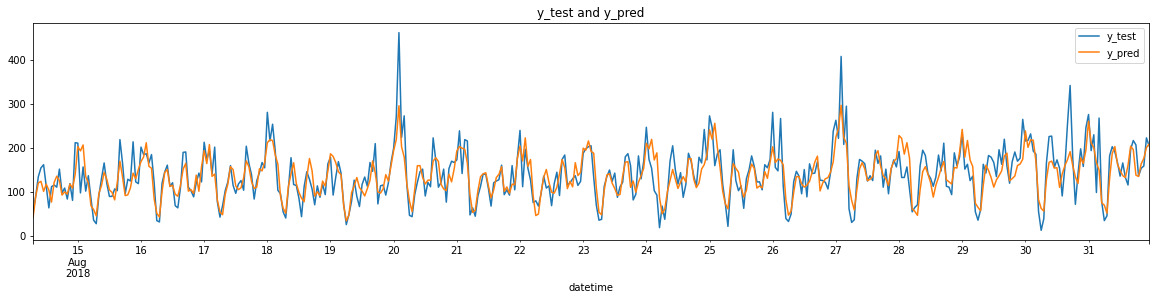

In [48]:
report = pd.DataFrame ({"y_test": y_test, "y_pred": y_pred})

report.plot(figsize=(20, 4))
plt.title(f'y_test and y_pred');

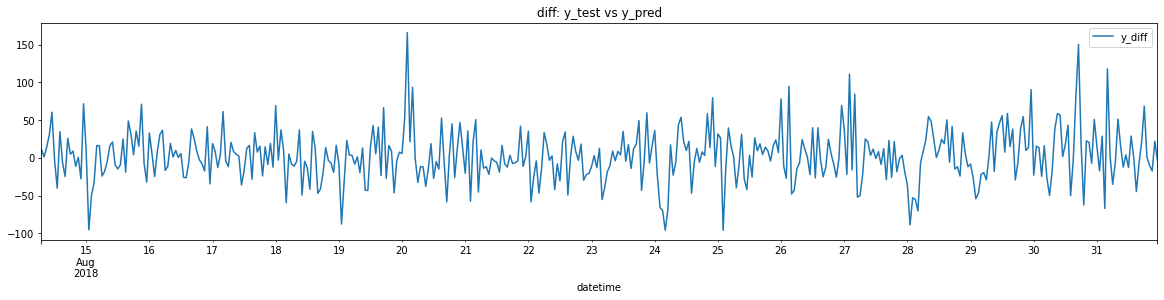

In [49]:
report = pd.DataFrame ({"y_diff": y_test-y_pred})

report.plot(figsize=(20, 4))
plt.title(f'diff: y_test vs y_pred');

In [50]:
'''v2
diff_avg = (y_test-y_pred).mean()
y_avg = y_test.mean()
display(diff_avg, y_avg, diff_avg/y_avg)'''

'v2\ndiff_avg = (y_test-y_pred).mean()\ny_avg = y_test.mean()\ndisplay(diff_avg, y_avg, diff_avg/y_avg)'

In [51]:
pred_previous = y_test.shift()
pred_previous.iloc[0] = y_train.iloc[-1]

In [52]:
mean_squared_error(y_test, pred_previous)**0.5

58.819724582830204

# Отчёт и выводы

- В соответствии с поставленной задачей(см. первый раздел)
    - были загружены данные
    - проведён их анализ:
        - Все данные - с марта по август 2018 года
        - Значимых всплесков или провалов не обнаружено в статистикеах по: меяцам, дням недели, дням месяца, часу
        - Выялвлен тренд роста количества заказов к августу (растёт и среднее, и разбос)
    - сконструированы дополнительные признаки: час, день недели, лаги с шагом в 24 часа, скользящие средние для 3, 5 и 10 часов (за исключением текущего)
    - при помощи pipeline с перебором гиперпараметров было натренировано несколько моделей, предсказывающая количество заказов в следующщий час
        - выбрана наиболее оптимальная модель - **LinearRegression**, показавшая наилучшие результаты:
            - качество предсказания на тестовой выборке: rmse = 34
            - это удовлетворяет заданный критерий качества: rmse <= 48
        - анализ остатков показывает, что распределение похоже на нормальное, а дисперсия остатков распределена равеномерно
    